In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append("..")
import sourse
import sourse_new

In [2]:
x_length = 0.02  # x方向の長さ m
y_length = 0.04  # y方向の長さ m
mesh_length = 1.0e-5  # m
nx = int(x_length / mesh_length)  # how many mesh
ny = int(y_length / mesh_length)

dx = x_length / nx  # mesh length m
dy = y_length / ny  # m

rho = 7840  # density kg/m^3
E = 206 * 1e9  # young percentage kg/ms^2
G = 80 * 1e9  # stiffness
V = 0.27  # poisson ratio

cl = np.sqrt(E / rho * (1 - V) / (1 + V) / (1 - 2 * V))  # P wave
ct = np.sqrt(G / rho)  # S wave
c11 = E * (1 - V) / (1 + V) / (1 - 2 * V)
c13 = E * V / (1 + V) / (1 - 2 * V)
c55 = (c11 - c13) / 2

dt = dx / cl / np.sqrt(6)  # time mesh
f = 4.7e6  # frequency
T = 1 / f  # period
lam = cl / f  # lambda
k = 1 / lam  # wave number
n = T / dt  # 波が離散点上で何点か

In [3]:
# ==========================================

# 音源の位置
sy = int(ny / 2)
sx = 0
# 探触子の直径 m
probe_d = 0.007
sy_l = sy - int(probe_d / mesh_length / 2)
sy_r = sy + int(probe_d / mesh_length / 2)

t_max = 4 * x_length / cl / dt  # 1往復ちょいの時間

#  =====================================================================================
#  =====================================================================================
wave = np.zeros(int(t_max))
# 傷の幅 m
f_width = 0.25e-3  # m
# 傷の間隔 m
f_pitch = 2.00e-3
# 傷の深さ m
f_depth = 0.20e-3  # m

print(f"f_pitch = {f_pitch}")
print(f"f_depth = {f_depth}")
#  傷の数
num_f = int(y_length / f_pitch)
#  傷の幅の離散点数
mn_w = int(f_width / mesh_length)
#  1ピッチの離散点数
mn_p = int(f_pitch / mesh_length)
# 傷のない部分の離散点数
mn_nf = int((f_pitch - f_width) / mesh_length)
# 傷の深さ方向の離散点数
mn_d = int(f_depth / mesh_length)
#  =========================================================================================

f_pitch = 0.002
f_depth = 0.0002


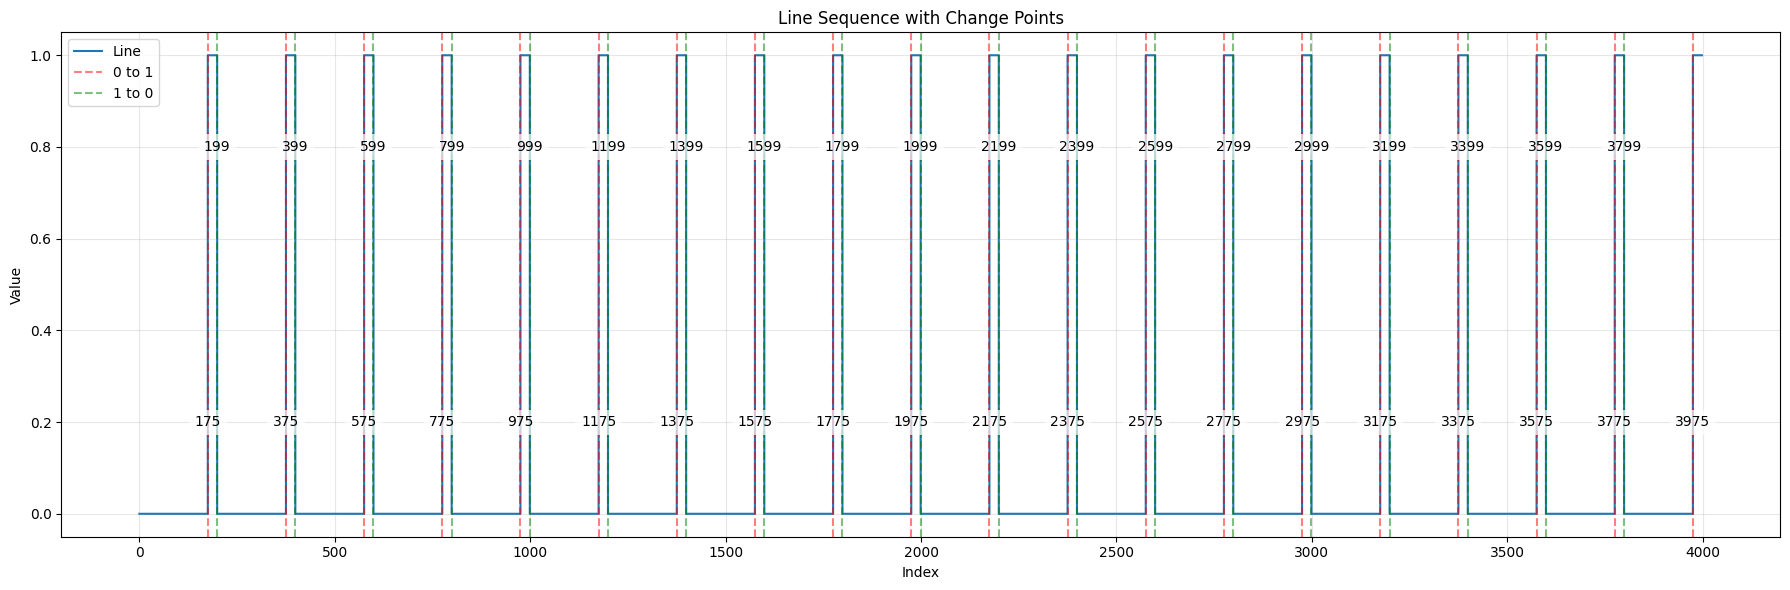

In [4]:
line = np.zeros(sourse.ny)
for i in range(num_f):
    line[mn_nf + i * mn_p : (i + 1) * mn_p - 1] = 1
# 変化点を見つける
change_points = np.where(np.diff(line) != 0)[0] + 1

# プロット
plt.figure(figsize=(18, 6))
plt.step(range(len(line)), line, where="post", label="Line")

# 変化点を強調表示
for cp in change_points:
    if line[cp] == 1:
        plt.axvline(x=cp, color="r", linestyle="--", alpha=0.5, label="0 to 1" if cp == change_points[0] else "")
    else:
        plt.axvline(x=cp, color="g", linestyle="--", alpha=0.5, label="1 to 0" if cp == change_points[1] else "")

plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Line Sequence with Change Points")
plt.legend()
plt.grid(True, alpha=0.3)


# テキスト位置の調整関数
def adjust_text_positions(change_points, ax):
    texts = []
    y_positions = [0.2, 0.8]  # テキストの垂直位置（交互に配置）
    y_index = 0
    prev_x = -np.inf

    for cp in change_points:
        # 現在の変化点と前の変化点との距離を計算
        distance = cp - prev_x

        # 距離が近い場合、水平方向にずらす
        x_offset = 0
        if distance < 10:  # この値は調整可能
            x_offset = (10 - distance) / 2

        # テキストを配置し、リストに追加
        text = ax.text(
            cp + x_offset,
            y_positions[y_index],
            f"{cp}",
            horizontalalignment="center",
            verticalalignment="center",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
        )
        texts.append(text)

        # 次のテキストの準備
        y_index = (y_index + 1) % 2
        prev_x = cp

    return texts


# メインの図にテキストを追加
texts = adjust_text_positions(change_points, plt.gca())

plt.tight_layout()
plt.show()

In [5]:
(1.75 * 0.001) / (sourse_new.dt * 500)

4910.013662463577

In [6]:
(2775 - 1399) * sourse_new.mesh_length

0.013760000000000001

In [7]:
(((2775 - 1399) * sourse_new.mesh_length) / sourse_new.cl) / sourse_new.dt

3368.8126371266176